# Fitting and correction pipeline

This notebook provides a reusable pipeline to:

- Load a raw CSV from the ultrasonic distance sensor
- Clean the data (drop nulls and remove per-trial outliers)
- Plot expected vs actual distances with an identity line and best-fit line
- Visualize error distributions and regression residuals
- Fit a simple correction model (constant offset + quantization bin of 2.5 mm) and plot corrected results.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

STRENGTH_TOLERANCE = 2000.0  # Adjust this based on expected strength variability

sns.set(style="whitegrid")
%matplotlib inline


In [16]:
# Basic loading and cleaning helpers

# Data directory relative to this notebook (scripts/ -> ../data)
DATA_DIR = Path("../data")

REQUIRED_COLUMNS = [
    "trial",
    "register",
    "rdistance",
    "strength",
    "edistance",
]


def load_raw_csv(csv_path, register: int | None = 0) -> pd.DataFrame:
    """Load a raw CSV and (optionally) filter to one register.

    Parameters
    ----------
    csv_path : str or Path
        Path to the raw CSV file.
    register : int or None
        If not None, filter to this register.
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.dropna(subset=REQUIRED_COLUMNS).copy()
    if register is not None:
        df = df[df["register"] == register].copy()

    df["error_mm"] = df["rdistance"] - df["edistance"]
    return df


def remove_outliers_per_trial(
    df: pd.DataFrame,
    value_col: str = "rdistance",
    trial_col: str = "trial",
    n_std: float = 2.0,
) -> pd.DataFrame:
    """Remove per-trial outliers based on median ± n_std * std in value_col.

    This mirrors the logic in the sensor analysis notebook.
    """

    def keep_inliers(g: pd.DataFrame) -> pd.DataFrame:
        med = g[value_col].median()
        std = g[value_col].std()
        if std == 0 or pd.isna(std):
            return g
        return g[abs(g[value_col] - med) <= n_std * std]

    return (
        df.groupby(trial_col, group_keys=False)
        .apply(keep_inliers)
        .reset_index(drop=True)
    )


def clean_data(df: pd.DataFrame, value_col: str = "rdistance", n_std: float = 2.0) -> pd.DataFrame:
    """Drop nulls, recompute error_mm, and remove per-trial outliers.

    Parameters
    ----------
    df : pd.DataFrame
        Raw data with required columns.
    value_col : str
        Column used for outlier detection (typically 'rdistance').
    n_std : float
        How many std devs from the trial median to keep.
    """
    work = df.dropna(subset=REQUIRED_COLUMNS).copy()
    work["error_mm"] = work["rdistance"] - work["edistance"]
    cleaned = remove_outliers_per_trial(work, value_col=value_col, trial_col="trial", n_std=n_std)
    return cleaned


def get_trial_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-trial stats (similar to get_stats in sensor_analysis).

    Returns columns:
    - expected_distance
    - median_distance, mean_distance, std_distance
    - median_error, mean_error
    - count, mean_strength, median_strength
    """
    work = df.copy()
    if "error_mm" not in work.columns:
        work["error_mm"] = work["rdistance"] - work["edistance"]
    work["abs_strength"] = work["strength"].abs()
    stats = (
        work.groupby("trial")
        .agg(
            expected_distance=("edistance", "median"),
            median_distance=("rdistance", "median"),
            mean_distance=("rdistance", "mean"),
            std_distance=("rdistance", "std"),
            median_error=("error_mm", "median"),
            mean_error=("error_mm", "mean"),
            count=("rdistance", "size"),
            mean_strength=("abs_strength", "mean"),
            median_strength=("abs_strength", "median"),
        )
        .reset_index()
    )
    return stats


def strength_rejection(
    df: pd.DataFrame,
    strength_col: str = "strength",
    strength_center: float | None = None,
    strength_tol: float = STRENGTH_TOLERANCE,
    use_abs: bool = True,
) -> tuple[pd.DataFrame, float]:
    """Reject measurements whose strength is far from the probable object strength.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned data (after null drop / outlier removal).
    strength_col : str
        Column containing strength values.
    strength_center : float or None
        Center strength. If None, estimated as the median of |strength| (or strength).
    strength_tol : float
        Allowed deviation from center (in strength units). Rows outside
        [center - strength_tol, center + strength_tol] are dropped.
    use_abs : bool
        If True, operate on abs(strength); otherwise use signed strength.

    Returns
    -------
    filtered_df : pd.DataFrame
        DataFrame with out-of-band strength measurements removed.
    center : float
        The strength_center actually used.
    """
    work = df.copy()
    s = work[strength_col].abs() if use_abs else work[strength_col]
    if strength_center is None:
        strength_center = float(s.median())
    lower = strength_center - strength_tol
    upper = strength_center + strength_tol
    if use_abs:
        mask = (s >= lower) & (s <= upper)
    else:
        mask = (work[strength_col] >= lower) & (work[strength_col] <= upper)
    filtered = work[mask].reset_index(drop=True)
    return filtered, strength_center


In [17]:
# Plotting and regression helpers

def plot_expected_vs_actual(
    stats: pd.DataFrame,
    use_mean: bool = False,
    title: str | None = None,
    ax=None,
):
    """Scatter of expected vs actual with identity line and best-fit line.

    Stats is typically the output of get_trial_stats().
    """
    y_col = "mean_distance" if use_mean else "median_distance"
    stats = stats.dropna(subset=["expected_distance", y_col]).copy()
    if stats.empty:
        raise ValueError("No valid rows after dropping NaNs for expected_distance / actual distance")

    x = stats["expected_distance"].values
    y = stats[y_col].values

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(x, y, label="data")

    # Identity line y = x
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, x_line, "k--", label="y = x")

    # Best-fit line
    if len(x) >= 2:
        slope, intercept, r, p, se = linregress(x, y)
        ax.plot(x_line, slope * x_line + intercept, "r-", label=f"fit (R²={r**2:.3f})")
        ax.text(
            0.05,
            0.95,
            f"y = {slope:.4f} x + {intercept:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
        )

    ax.set_xlabel("expected_distance (mm)")
    ax.set_ylabel(f"{y_col} (mm)")
    ax.set_title(title or "Expected vs actual distance")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax


def plot_error_summaries(stats: pd.DataFrame, use_mean: bool = False):
    """Graphical representations of error vs expected and error histogram."""
    err_col = "mean_error" if use_mean else "median_error"
    stats = stats.dropna(subset=["expected_distance", err_col]).copy()
    if stats.empty:
        raise ValueError("No valid rows after dropping NaNs for expected_distance / error")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.scatterplot(
        data=stats,
        x="expected_distance",
        y=err_col,
        ax=axes[0],
    )
    axes[0].axhline(0, color="k", linestyle="--", alpha=0.7)
    axes[0].set_xlabel("expected_distance (mm)")
    axes[0].set_ylabel(f"{err_col} (mm)")
    axes[0].set_title("Error vs expected distance")

    sns.histplot(stats[err_col], bins=30, kde=True, ax=axes[1])
    axes[1].axvline(0, color="k", linestyle="--", alpha=0.7)
    axes[1].set_xlabel(f"{err_col} (mm)")
    axes[1].set_title("Error distribution")

    plt.tight_layout()
    return axes


def fit_linear_model(stats: pd.DataFrame, use_mean: bool = False) -> dict | None:
    """Fit line of best fit y = slope * x + intercept.

    Returns dict with slope, intercept, R^2, etc.
    """
    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col])
    if len(s) < 2:
        return None
    slope, intercept, r, p, se = linregress(s["expected_distance"], s[y_col])
    return {
        "slope": float(slope),
        "intercept": float(intercept),
        "r_squared": float(r**2),
        "p_value": float(p),
        "std_err": float(se),
    }


def plot_regression_residuals(
    stats: pd.DataFrame,
    fit: dict,
    use_mean: bool = False,
):
    """Plot residuals of the regression line (scatter vs expected + histogram)."""
    if fit is None:
        raise ValueError("fit is None; run fit_linear_model first")

    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col]).copy()
    x = s["expected_distance"].values
    y = s[y_col].values
    y_pred = fit["slope"] * x + fit["intercept"]
    resid = y - y_pred
    s["residual"] = resid

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(x, resid)
    axes[0].axhline(0, color="k", linestyle="--", alpha=0.7)
    axes[0].set_xlabel("expected_distance (mm)")
    axes[0].set_ylabel("residual (mm)")
    axes[0].set_title("Residuals vs expected distance")
    axes[0].grid(True, alpha=0.3)

    sns.histplot(resid, bins=30, kde=True, ax=axes[1])
    axes[1].axvline(0, color="k", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("residual (mm)")
    axes[1].set_title("Residual distribution")

    plt.tight_layout()
    return axes


In [18]:
# Constant-offset correction model with quantization bin

def fit_constant_offset(df_clean: pd.DataFrame, bin_size_mm: float = 2.5) -> dict:
    """Fit a constant offset model using the mean error.

    Measurement model:
        measured ≈ true + offset + quantization_error,
    where quantization_error is in approximately [-bin_size_mm, +bin_size_mm].
    """
    if "error_mm" not in df_clean.columns:
        df_clean = df_clean.copy()
        df_clean["error_mm"] = df_clean["rdistance"] - df_clean["edistance"]

    err = df_clean["error_mm"].dropna()
    offset = err.mean()  # optimal constant offset in least-squares sense
    err_std = err.std()

    return {
        "offset_mm": float(offset),
        "offset_std_mm": float(err_std),
        "bin_size_mm": float(bin_size_mm),
        "n_samples": int(err.shape[0]),
    }


def apply_offset_correction(df_clean: pd.DataFrame, offset_mm: float) -> pd.DataFrame:
    """Apply a constant offset correction to rdistance and recompute errors."""
    corrected = df_clean.copy()
    corrected["rdistance_corrected"] = corrected["rdistance"] - offset_mm
    corrected["error_corrected_mm"] = corrected["rdistance_corrected"] - corrected["edistance"]
    return corrected


def fit_slope_one_offset(stats: pd.DataFrame, use_mean: bool = False) -> dict | None:
    """Fit best constant offset for a slope-1 line (y = x + b) and report mean error.

    Uses per-trial stats (expected_distance vs median/mean_distance).
    Error is defined as (y - (x + b)).
    """
    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col])
    if len(s) < 2:
        return None
    x = s["expected_distance"].values
    y = s[y_col].values
    # For slope 1, optimal offset b is mean(y - x)
    offset = float((y - x).mean())
    residuals = y - (x + offset)
    mean_error = float(residuals.mean())
    mean_abs_error = float(abs(residuals).mean())
    std_error = float(residuals.std())
    return {
        "offset_mm": offset,
        "mean_error_mm": mean_error,
        "mean_abs_error_mm": mean_abs_error,
        "std_error_mm": std_error,
        "n_points": int(len(s)),
    }


def plot_corrected_vs_expected(
    df_corrected: pd.DataFrame,
    bin_size_mm: float = 2.5,
    aggregate: bool = True,
):
    """Plot corrected distances vs expected with ±bin_size_mm band.

    If aggregate=True, plot per-trial medians; otherwise plot all samples.
    """
    if aggregate:
        work = df_corrected.copy()
        if "rdistance_corrected" not in work.columns:
            raise ValueError("expected 'rdistance_corrected' in df_corrected")
        stats = (
            work.groupby("trial")
            .agg(
                expected_distance=("edistance", "median"),
                median_corrected=("rdistance_corrected", "median"),
            )
            .reset_index()
        )
        x = stats["expected_distance"].values
        y = stats["median_corrected"].values
    else:
        x = df_corrected["edistance"].values
        y = df_corrected["rdistance_corrected"].values

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x, y, label="corrected data", alpha=0.8)

    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, x_line, "k--", label="y = x")

    # quantization band ± bin_size_mm
    ax.plot(x_line, x_line + bin_size_mm, "r:", label=f"y = x ± {bin_size_mm:.1f} mm")
    ax.plot(x_line, x_line - bin_size_mm, "r:")

    ax.set_xlabel("expected_distance (mm)")
    ax.set_ylabel("corrected distance (mm)")
    ax.set_title("Corrected distance vs expected with bin band")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax


def summarize_corrected_errors(df_corrected: pd.DataFrame) -> dict:
    """Summarize corrected errors and fraction within ±2.5 mm."""
    if "error_corrected_mm" not in df_corrected.columns:
        raise ValueError("expected 'error_corrected_mm' in df_corrected")
    err = df_corrected["error_corrected_mm"].dropna()
    summary = {
        "mean_error_mm": float(err.mean()),
        "std_error_mm": float(err.std()),
        "median_error_mm": float(err.median()),
        "p_within_2p5mm": float((err.abs() <= 2.5).mean()),
        "n": int(err.shape[0]),
    }
    return summary


Loaded 400 raw rows from ..\data\profile_back_greenpvc_90-145-5mm_profile2_snr35000_CFAR_calibrate-aware.csv
After cleaning: 366 rows


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\caden\AppData\Local\Temp\ipykernel_46464\1120398014.py:4: SyntaxWarning: invalid escape sequence '\d'
  CSV_PATH = Path("..\data\profile_back_greenpvc_90-145-5mm_profile2_snr35000_CFAR_calibrate-aware.csv") # <-- change to your file
C:\Users\caden\AppData\Local\Temp\ipykernel_46464\26092965.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_inliers)


,trial,expected_distance,median_distance,mean_distance,std_distance,median_error,mean_error,count,mean_strength,median_strength
0,0,145.0,139.0,139.00,0.000000,-6.0,-6.00,44,1581.681818,1589.5
1,1,140.0,135.0,135.00,0.000000,-5.0,-5.00,33,1279.151515,1258.0
2,2,135.0,129.0,129.00,0.000000,-6.0,-6.00,45,2819.666667,2810.0
3,3,130.0,122.0,122.00,0.000000,-8.0,-8.00,50,5864.660000,5842.0
4,4,125.0,114.0,113.54,0.503457,-11.0,-11.46,50,9597.200000,9591.5


Linear regression fit: {'slope': 1.2357142857142858, 'intercept': -39.178571428571445, 'r_squared': 0.9897919813036722, 'p_value': 3.336905566474837e-07, 'std_err': 0.051231987598451996}


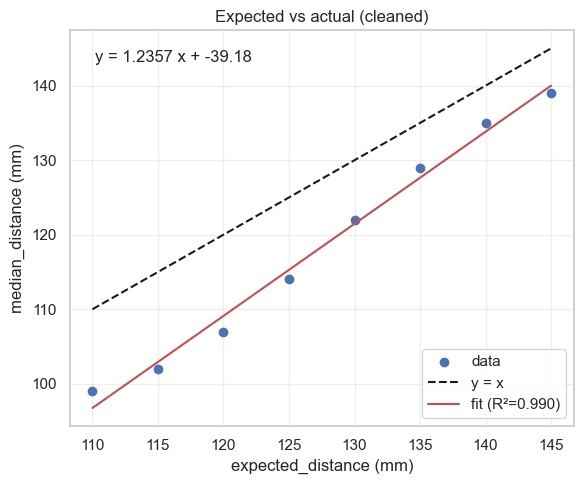

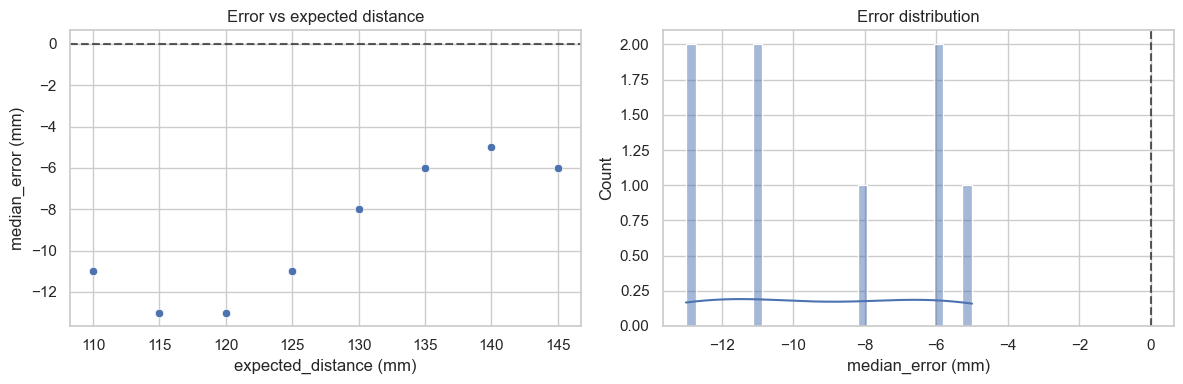

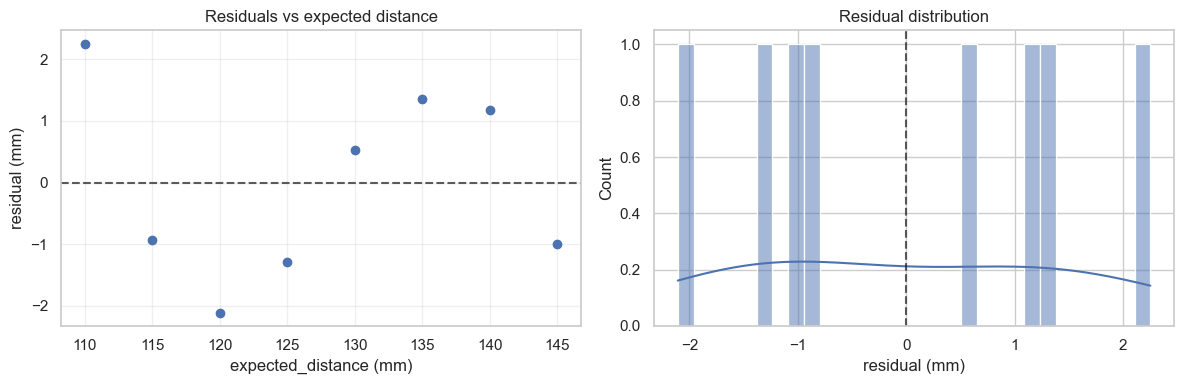

Strength rejection: center≈2774.0, tol=2000.0, kept 217/366 rows


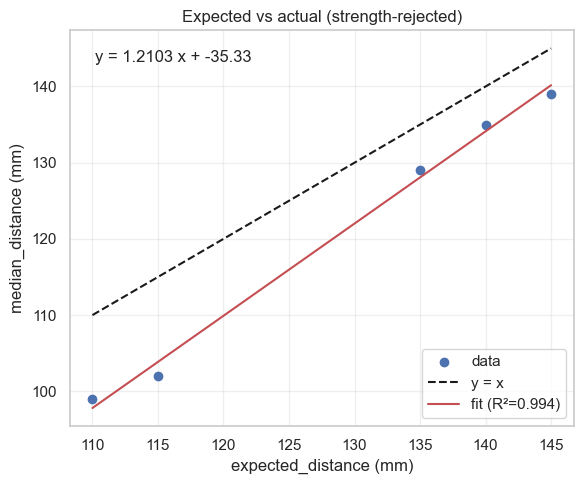

Offset model: {'offset_mm': -9.40983606557377, 'offset_std_mm': 3.0234356716694184, 'bin_size_mm': 2.5, 'n_samples': 366}
Corrected error summary: {'mean_error_mm': -6.833635054304788e-15, 'std_error_mm': 3.023435671669412, 'median_error_mm': -1.5901639344262293, 'p_within_2p5mm': 0.3469945355191257, 'n': 366}
Corrected (strength-rejected) error summary: {'mean_error_mm': 0.9582231623479563, 'std_error_mm': 3.1796094678404834, 'median_error_mm': 3.4098360655737565, 'p_within_2p5mm': 0.2304147465437788, 'n': 217}


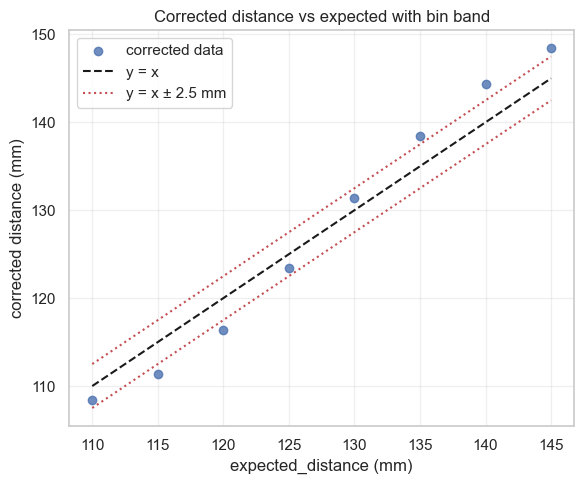

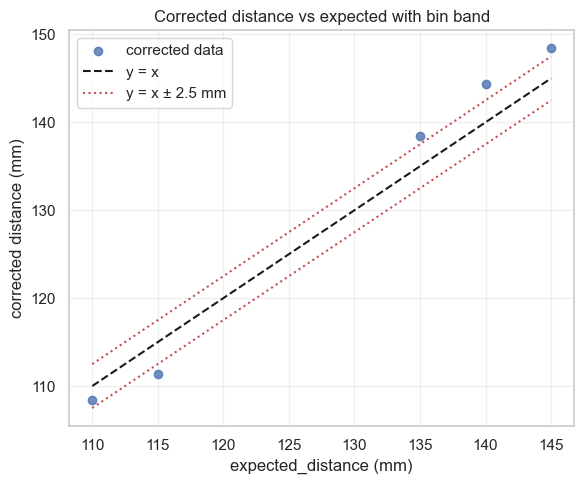

In [20]:
# End-to-end pipeline for one CSV

# Configure these for your run
CSV_PATH = Path("..\data\profile_back_greenpvc_90-145-5mm_profile2_snr35000_CFAR_calibrate-aware.csv") # <-- change to your file
REGISTER = 0  # which register to analyze (None = all)
BIN_SIZE_MM = 2.5
N_STD = 2.0  # outlier threshold in std devs from trial median
USE_MEAN = False  # False = use medians, True = use means


# 1. Load raw data
raw = load_raw_csv(CSV_PATH, register=REGISTER)
print(f"Loaded {len(raw)} raw rows from {CSV_PATH}")

# 2. Clean data (drop nulls + per-trial outlier removal)
clean = clean_data(raw, value_col="rdistance", n_std=N_STD)
print(f"After cleaning: {len(clean)} rows")

# 3. Aggregate per-trial stats
stats = get_trial_stats(clean)
display(stats.head())

# 4. Fit regression and plot expected vs actual
fit = fit_linear_model(stats, use_mean=USE_MEAN)
print("Linear regression fit:", fit)

plot_expected_vs_actual(stats, use_mean=USE_MEAN, title="Expected vs actual (cleaned)")
plt.show()

# 5. Plot error summaries
plot_error_summaries(stats, use_mean=USE_MEAN)
plt.show()

# 6. Plot regression residuals
plot_regression_residuals(stats, fit, use_mean=USE_MEAN)
plt.show()

# 7. Strength-based rejection and expected vs actual
strength_tol = 2000.0
clean_sr, strength_center = strength_rejection(clean, strength_col="strength")
print(
    f"Strength rejection: center≈{strength_center:.1f}, "
    f"tol={strength_tol:.1f}, kept {len(clean_sr)}/{len(clean)} rows"
)
stats_sr = get_trial_stats(clean_sr)
plot_expected_vs_actual(
    stats_sr,
    use_mean=USE_MEAN,
    title="Expected vs actual (strength-rejected)",
)
plt.show()

# 8. Fit constant offset model and apply correction
offset_model = fit_constant_offset(clean, bin_size_mm=BIN_SIZE_MM)
print("Offset model:", offset_model)

corrected = apply_offset_correction(clean, offset_model["offset_mm"])
corr_summary = summarize_corrected_errors(corrected)
print("Corrected error summary:", corr_summary)

# Also apply the same offset to strength-rejected data
corrected_sr = apply_offset_correction(clean_sr, offset_model["offset_mm"])
corr_summary_sr = summarize_corrected_errors(corrected_sr)
print("Corrected (strength-rejected) error summary:", corr_summary_sr)

# 9. Plot corrected distances vs expected with ±2.5 mm band
plot_corrected_vs_expected(corrected, bin_size_mm=BIN_SIZE_MM, aggregate=True)
plt.show()

# 10. Plot strength-rejected corrected distances vs expected with ±2.5 mm band
plot_corrected_vs_expected(
    corrected_sr,
    bin_size_mm=BIN_SIZE_MM,
    aggregate=True,
)
plt.show()
